## Regression Analysis

A linear regression model was used to analyze factors associated with profit in the
Global Superstore dataset. The model was evaluated on a held-out test set and achieved
modest predictive performance (R² ≈ 0.13), reflecting the inherently noisy nature of
retail profit data.

Despite limited predictive power, coefficient analysis revealed clear business insights.
Discounts and shipping costs showed strong negative associations with profit, while sales
had only a modest positive effect. Higher order quantities were also associated with lower
profit, suggesting that bulk purchasing and aggressive discounting reduce margins.

These results highlight the importance of cost control and pricing strategy over sales
volume alone in driving profitability.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


## Data Loading and Preparation

The dataset contains detailed records of orders across multiple regions, product
categories, and customer segments. It includes both numerical and categorical variables
related to sales, discounts, shipping, and profit.


In [3]:
df = pd.read_csv("../data/Superstore.csv")
df.head()


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [4]:
y = df['Profit']


## Profit Distribution

Before modeling, the distribution of profit is examined to understand skewness,
outliers, and the presence of losses. Retail profit data typically contains both
positive and negative values, which influences modeling decisions.


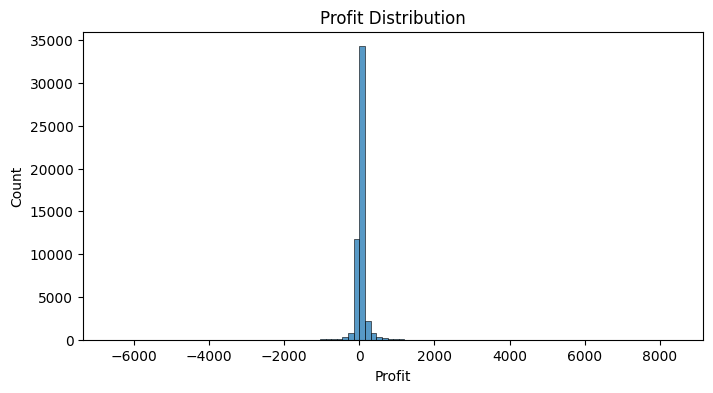

In [5]:
plt.figure(figsize=(8,4))
sns.histplot(df['Profit'], bins=100)
plt.title("Profit Distribution")
plt.show()


## Feature Selection

Features were selected based on their relevance to business decision-making. The model
focuses on variables that influence revenue, discounting, logistics costs, and customer
segmentation.


In [6]:
features = [
    'Sales',
    'Discount',
    'Quantity',
    'Shipping.Cost',
    'Segment',
    'Category',
    'Market',
    'Ship.Mode'
]

X = df[features]
y = df['Profit']


## Encoding Categorical Variables

Categorical features such as segment, category, market, and shipping mode are converted
into numerical form using one-hot encoding. A baseline category is dropped to avoid
multicollinearity and allow coefficient interpretation relative to a reference group.


In [7]:
X = pd.get_dummies(X, drop_first=True)


In [8]:
X.shape

(51290, 17)

## Train-Test Split

The dataset is split into training and test sets to evaluate model performance on unseen
data. This helps assess how well the model generalizes beyond the data it was trained on.


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Model Training

A linear regression model is trained to establish a baseline understanding of how
selected features are associated with profit. Linear regression is chosen for its
interpretability and suitability for business analysis.


In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Model Evaluation

Model performance is evaluated on the test set using Root Mean Squared Error (RMSE) and
R². Given the noisy nature of retail profit data, these metrics are interpreted as
indicators of general trends rather than precise prediction accuracy.


In [11]:
#Test Data
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

rmse, r2


(np.float64(160.17813646510862), 0.12675991496061267)

## Coefficient Interpretation

Although the model exhibits modest predictive performance, coefficient analysis provides
valuable insights into how individual features are associated with profit. Coefficients
represent the expected change in profit for a one-unit change in the corresponding
feature, holding all other variables constant.


In [12]:
coef = pd.Series(model.coef_, index=X.columns)
coef_sorted = coef.sort_values(ascending=False)

coef_sorted.head(10), coef_sorted.tail(10)


(Category_Office Supplies    38.565963
 Category_Technology         22.543126
 Market_US                    8.918207
 Market_EMEA                  2.448260
 Market_Africa                1.858538
 Market_LATAM                 1.335941
 Segment_Home Office          0.522911
 Sales                        0.234274
 Ship.Mode_Same Day          -0.384001
 Shipping.Cost               -0.384533
 dtype: float64,
 Sales                         0.234274
 Ship.Mode_Same Day           -0.384001
 Shipping.Cost                -0.384533
 Segment_Corporate            -0.904718
 Quantity                     -4.872415
 Ship.Mode_Second Class       -6.534839
 Market_Canada                -8.049515
 Market_EU                    -9.201824
 Ship.Mode_Standard Class     -9.274445
 Discount                   -217.748241
 dtype: float64)

## Key Insights

- Discounts have a strong negative association with profit, indicating that aggressive
  discounting significantly reduces margins.
- Shipping costs are directly associated with lower profit, highlighting the importance
  of logistics efficiency.
- Increased order quantity does not necessarily improve profitability, suggesting that
  bulk orders often come with lower margins.
- Sales volume alone has a relatively modest impact on profit compared to cost-related
  factors.


In [13]:
coef[['Sales', 'Discount', 'Quantity', 'Shipping.Cost']]


Sales              0.234274
Discount        -217.748241
Quantity          -4.872415
Shipping.Cost     -0.384533
dtype: float64

## Conclusion

This analysis demonstrates that profit in the Global Superstore dataset is driven more by
cost control and pricing strategy than by sales volume alone. While the regression model
has limited predictive power due to missing cost and operational variables, it provides
clear and actionable business insights.

The results emphasize the importance of managing discounts, shipping costs, and customer
segmentation to improve overall profitability.
